In [9]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:

def writebin(filename, array):
    """Write array as big-endian float32 binary."""
    array.astype('>f4').tofile(filename)

# create tidal input files
nx = 40
nTidalComp = 4

for ob in ['N', 'S']:
    OBlength = nx

    for fld in ['am', 'ph']:
        fnm1 = f'tidalComp.OB{ob}{fld}Nvel.bin'
        fnm2 = f'tidalComp.OB{ob}{fld}Tvel.bin'

        var1 = np.zeros((OBlength, nTidalComp), dtype=np.float32)
        var2 = np.zeros_like(var1)

        # North boundary: component 3
        if ob == 'N':
            if fld == 'am':
                var1[:, 2] += 0.03
            else:
                var1[:, 2] += 6 * 3600

        # South boundary: component 1
        if ob == 'S':
            if fld == 'am':
                var1[:, 0] += 0.1
            else:
                var1[:, 0] += 2 * 3600

            # Tangential velocity for South boundary
            if fld == 'am':
                var2[:, 0] = var1[:, 0] + 0.01
            else:
                var2[:, 0] += 3 * 3600

        # East boundary: component 2
        if ob == 'E':
            if fld == 'am':
                var1[:, 1] += 0.1
            else:
                var1[:, 1] += 4 * 3600

            # Tangential velocity for East boundary
            if fld == 'am':
                var2[:, 1] += 0.01
            else:
                var2[:, 1] += 5 * 3600

        # West boundary: component 4
        if ob == 'W':
            if fld == 'am':
                var1[:, 3] += 0.02
            else:
                var1[:, 3] += 8 * 3600

        print(f'writing bin file: {fnm1} ...', end='')
        writebin(fnm1, var1)
        print(' done')

        if ob in ['S', 'E']:
            print(f'writing bin file: {fnm2} ...', end='')
            writebin(fnm2, var2)
            print(' done')

writing bin file: tidalComp.OBNamNvel.bin ... done
writing bin file: tidalComp.OBNphNvel.bin ... done
writing bin file: tidalComp.OBSamNvel.bin ... done
writing bin file: tidalComp.OBSamTvel.bin ... done
writing bin file: tidalComp.OBSphNvel.bin ... done
writing bin file: tidalComp.OBSphTvel.bin ... done


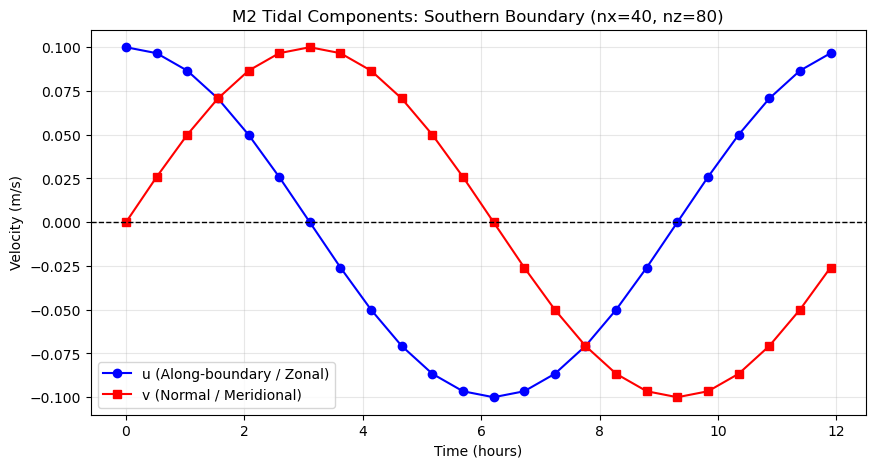

Files saved successfully.
Set externForcingPeriod = 1863.0 in your 'data' file.
Set externForcingCycle = 44712.0 in your 'data' file.


In [17]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Parameters
nx = 40              # Grid points in X
nz = 80              # Vertical levels
m2_period = 44712.0  # M2 period in seconds (~12.42 hours)
n_time = 24          # Number of records to save (2 per hour)
amplitude = 0.1      # 0.1 m/s velocity

# 2. Time and Signal Generation
dt_forcing = m2_period / n_time
t = np.linspace(0, m2_period, n_time, endpoint=False)
t_hours = t / 3600.0

# Components: u (along-boundary) and v (normal)
# Using Cos/Sin creates a 90-degree phase shift (circular ellipse)
u_signal = amplitude * np.cos(2 * np.pi * t / m2_period)
v_signal = amplitude * np.sin(2 * np.pi * t / m2_period)

# 3. Create and Save Binary Files
# MITgcm expects (Time, Nz, Nx) for Southern boundary files
u_data = np.zeros((n_time, nz, nx), dtype='>f4') # Big-endian 32-bit float
v_data = np.zeros((n_time, nz, nx), dtype='>f4')

for i in range(n_time):
    u_data[i, :, :] = u_signal[i]
    v_data[i, :, :] = v_signal[i]

u_data.tofile('OBSu_m2.bin')
v_data.tofile('OBSv_m2.bin')

# 4. Plot the Phases
plt.figure(figsize=(10, 5))
plt.plot(t_hours, u_signal, 'b-o', label='u (Along-boundary / Zonal)')
plt.plot(t_hours, v_signal, 'r-s', label='v (Normal / Meridional)')
plt.axhline(0, color='black', lw=1, ls='--')
plt.xlabel('Time (hours)')
plt.ylabel('Velocity (m/s)')
plt.title(f'M2 Tidal Components: Southern Boundary (nx={nx}, nz={nz})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Files saved successfully.")
print(f"Set externForcingPeriod = {dt_forcing} in your 'data' file.")
print(f"Set externForcingCycle = {m2_period} in your 'data' file.")


In [18]:
np.shape(v_data)

(24, 80, 40)

In [14]:
direction_rad = np.arctan2(v_data[:,10,10], u_data[:,10,10])
direction_deg = np.degrees(direction_rad)

# If you want 0-360 range
direction_deg = (direction_deg + 360) % 360

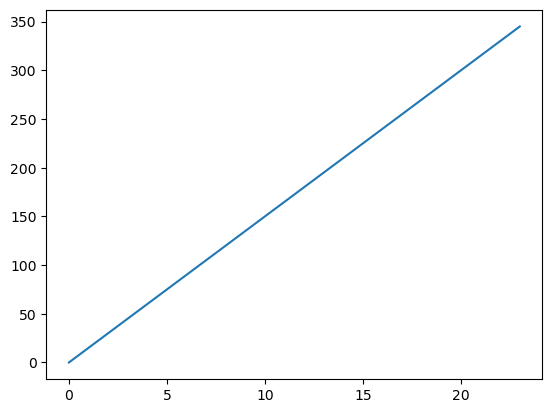

In [16]:
plt.plot(direction_deg)